# CNN으로 이미지 분류하기 🖼️
## Convolutional Neural Network (합성곱 신경망) 실습

**목표**: CIFAR-10 데이터셋으로 10가지 물체 이미지를 분류하는 CNN을 만들어봅니다.

**CIFAR-10 데이터셋**
- 32×32 픽셀의 컬러 이미지
- 10가지 클래스: ✈️비행기, 🚗자동차, 🐦새, 🐱고양이, 🦌사슴, 🐶개, 🐸개구리, 🐴말, 🚢배, 🚚트럭
- 학습 50,000장 + 테스트 10,000장

**CNN(합성곱 신경망)이란?**
- 이미지의 **공간적 특징(가장자리, 모양, 질감 등)**을 자동으로 학습하는 신경망
- MLP와 달리 이미지 구조를 그대로 활용 → 이미지 처리에 훨씬 강력!
- 합성곱(Convolution) → 풀링(Pooling) → 완전연결층(FC) 구조

## 우리가 풀 문제가 뭔지 먼저 확인해봅시다!

아래 이미지들은 CIFAR-10 데이터셋의 샘플입니다.  
우리의 목표는 AI가 이 사진을 보고 **10가지 종류 중 어떤 것인지 맞추는 것**입니다.

MNIST(흑백 28×28)와 달리 **컬러 32×32** 이미지라 훨씬 복잡합니다.  
MLP 대신 **CNN**을 쓰는 이유를 학습하면서 느껴보세요!

In [ ]:
import random
import torchvision
import matplotlib.pyplot as plt

CLASS_NAMES = ['Airplane', 'Car', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

preview_dataset = torchvision.datasets.CIFAR10(
    './cifar10',
    train=False,
    download=True
)

# 재현 가능하게 seed 고정
random.seed(42)

# 클래스별 이미지 index 모으기
class_to_indices = {i: [] for i in range(10)}

for idx, (_, label) in enumerate(preview_dataset):
    class_to_indices[label].append(idx)

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle('CIFAR-10 Sample Images — Can you guess them all?', fontsize=13)

# 각 클래스에서 랜덤하게 2장씩 뽑기
for class_idx in range(10):
    selected_indices = random.sample(class_to_indices[class_idx], 2)

    for row in range(2):
        ax = axes[row, class_idx]

        img_idx = selected_indices[row]
        img, label = preview_dataset[img_idx]

        ax.imshow(img)
        ax.set_title(f'{CLASS_NAMES[label]}\nidx={img_idx}', fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.show()

print("\n각 이미지는 32×32 픽셀 × 3채널(RGB) = 3,072개 숫자로 이루어져 있습니다.")
print("MLP였다면 3,072개를 한 줄로 펼쳐야 하지만, CNN은 구조를 그대로 활용합니다!")

**🗺️ 우리가 앞으로 밟을 단계** — 아래 순서대로 차근차근 진행합니다.

<div align="center">
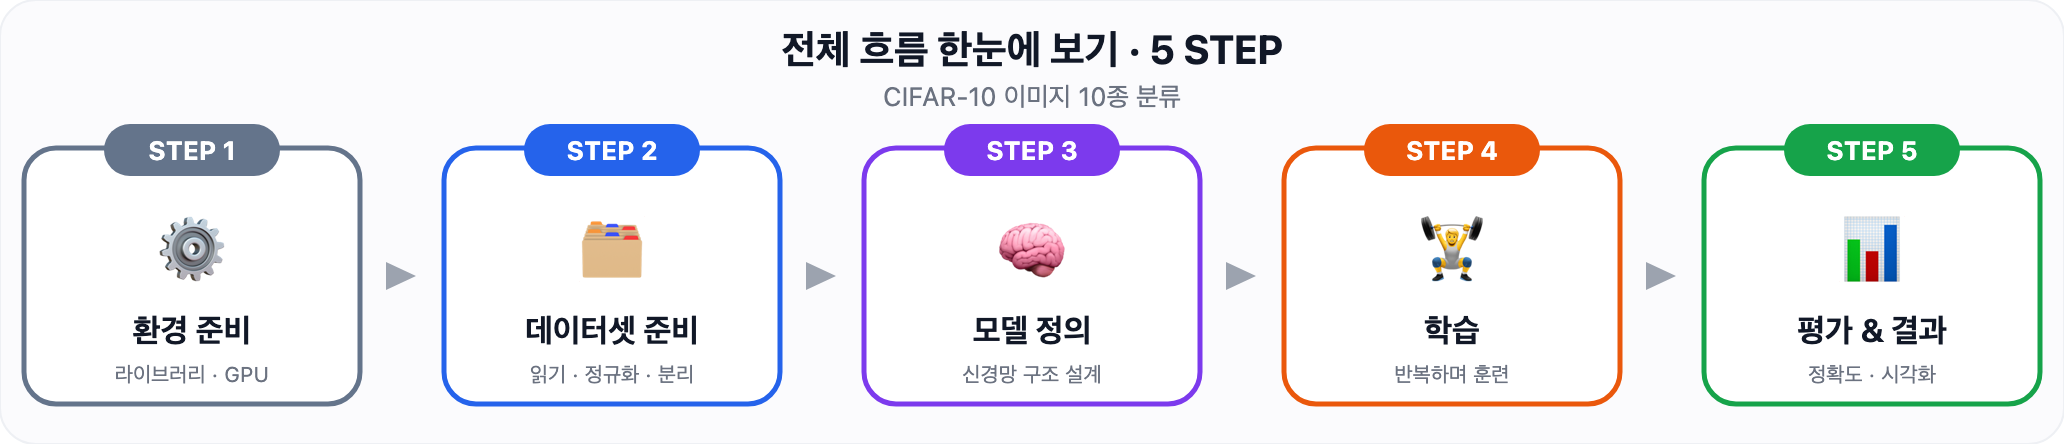
</div>

# ⚙️ STEP 1 · 환경 준비

본격적으로 시작하기 전에, 학습에 필요한 **도구(라이브러리)**를 불러오고 **계산 장치(GPU/CPU)**를 정합니다.

> **Colab GPU 활성화** (CIFAR-10 학습에는 꼭 필요!)
> 1. 상단 메뉴 → `런타임` → `런타임 유형 변경`
> 2. 하드웨어 가속기 → **T4 GPU** 선택 → 저장
>
> CIFAR-10 데이터셋은 첫 실행 시 자동으로 다운로드됩니다 (~170MB).

### 1-1. 라이브러리 불러오기

실습에 사용할 라이브러리를 한 번에 불러옵니다. 버전이 출력되면 성공입니다.

In [ ]:
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

print("PyTorch 버전:", torch.__version__)

### 1-2. 학습 장치(GPU/CPU) 선택

GPU가 있으면 자동으로 사용합니다. GPU를 쓰면 훨씬 빠르게 학습할 수 있습니다.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('현재 사용 장치:', device)

# 🗂️ STEP 2 · 데이터셋 준비

모델에게 먹일 데이터를 준비합니다. CIFAR-10을 **불러오면서 데이터 증강(augmentation)을 적용**하고, 실제 이미지를 눈으로 확인합니다.

### 2-1. 데이터셋 로드 & 데이터 증강

CIFAR-10을 불러오면서 변환(transform)을 적용합니다.
- **학습 데이터**: 좌우 반전·랜덤 크롭으로 **데이터 증강** → 다양한 형태를 학습
- **테스트 데이터**: 증강 없이 정규화만 적용
- train의 20%를 validation으로 분리합니다.

In [ ]:
from torch.utils.data import random_split

CLASS_NAMES = ['Airplane', 'Car', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

data_path  = './cifar10'
batch_size = 64

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),    # 좌우 반전 (데이터 증강)
    transforms.RandomCrop(32, padding=4), # 랜덤 크롭 (데이터 증강)
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

full_train   = torchvision.datasets.CIFAR10(data_path, train=True,  transform=transform_train, download=True)
test_dataset = torchvision.datasets.CIFAR10(data_path, train=False, transform=transform_test,  download=True)

# train의 20%를 validation으로 분리 (MLP에서와 동일한 방식)
val_size   = int(len(full_train) * 0.2)
train_size = len(full_train) - val_size
train_dataset, val_dataset = random_split(full_train, [train_size, val_size])

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_dataloader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f'학습:       {len(train_dataset)}장')
print(f'Validation: {len(val_dataset)}장')
print(f'테스트:     {len(test_dataset)}장')


In [ ]:
# 📊 그림: 데이터를 Train / Validation / Test 로 어떻게 나눴나?
import matplotlib.pyplot as plt

n_train, n_val, n_test = len(train_dataset), len(val_dataset), len(test_dataset)
n_full = n_train + n_val   # 학습용 = train + val

fig, ax = plt.subplots(figsize=(10, 2.6))
# 위 막대: 학습용 데이터를 8:2(train:val)로 분리
ax.barh(1, n_train, color='#2563eb', edgecolor='white')
ax.barh(1, n_val, left=n_train, color='#93c5fd', edgecolor='white')
# 아래 막대: 학습에 절대 쓰지 않고 따로 보관하는 test
ax.barh(0, n_test, color='#16a34a', edgecolor='white')

ax.text(n_train/2, 1, f'Train  {n_train:,}\n({n_train/n_full:.0%})', ha='center', va='center',
        color='white', fontsize=11, fontweight='bold')
ax.text(n_train + n_val/2, 1, f'Val\n{n_val:,}', ha='center', va='center',
        color='#1e3a8a', fontsize=9, fontweight='bold')
ax.text(n_test/2, 0, f'Test  {n_test:,}', ha='center', va='center',
        color='white', fontsize=11, fontweight='bold')

ax.set_yticks([0, 1])
ax.set_yticklabels(['Test set\n(= final exam)', 'Training set\n(= textbook + mock exam)'])
ax.set_xlabel('number of images')
ax.set_title('How the data is split   (Train : Val = 8 : 2,   Test kept completely separate)')
ax.set_xlim(0, max(n_full, n_test) * 1.05)
for s in ['top', 'right', 'left']:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

print(f'Train {n_train:,}  |  Val {n_val:,}  |  Test {n_test:,}')
print('Train=교과서로 공부  ·  Val=모의고사(중간 점검)  ·  Test=수능(맨 마지막 딱 한 번)')

In [ ]:
# 👀 확인: 정규화 전후 이미지 비교
def denormalize(tensor):
    return tensor * 0.5 + 0.5  # 정규화 역변환 (-1~1 → 0~1)

raw_dataset = torchvision.datasets.CIFAR10(data_path, train=False,
                                            transform=transforms.ToTensor(),
                                            download=False)
raw_img, label = raw_dataset[0]
norm_img, _    = test_dataset[0]

print('=== 정규화 전 ===')
print(f'shape: {raw_img.shape}  → (채널 3개, 32×32)')
print(f'값 범위: {raw_img.min():.2f} ~ {raw_img.max():.2f}  (0~1 실수)')
print()
print('=== 정규화 후 (평균 0.5, 표준편차 0.5 적용) ===')
print(f'shape: {norm_img.shape}')
print(f'값 범위: {norm_img.min():.2f} ~ {norm_img.max():.2f}  (-1~1 실수)')
print('→ 학습 안정성을 위해 픽셀값을 -1~1 범위로 맞춥니다.')

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(raw_img.permute(1, 2, 0))
axes[0].set_title('Before Norm\n0.0~1.0', fontsize=10)
axes[0].axis('off')
axes[1].imshow(denormalize(norm_img).permute(1, 2, 0).clamp(0, 1))
axes[1].set_title('After Norm (denorm. for display)\n-1.0~1.0', fontsize=10)
axes[1].axis('off')
plt.suptitle(f'Class: {CLASS_NAMES[label]}', fontsize=11)
plt.tight_layout()
plt.show()


### 2-2. 데이터 시각화

실제 데이터가 어떻게 생겼는지 확인해봅시다!

In [ ]:
sample_imgs, sample_labels = next(iter(train_dataloader))

# 정규화 역변환 (시각화용)
def denormalize(tensor):
    return tensor * 0.5 + 0.5

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = denormalize(sample_imgs[i]).permute(1, 2, 0).clamp(0, 1)
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[sample_labels[i]], fontsize=11)
    ax.axis('off')
plt.suptitle('CIFAR-10 Sample Images', fontsize=14)
plt.tight_layout()
plt.show()

# 🧠 STEP 3 · 모델 정의

이미지 분류 모델을 만듭니다. 먼저 **MLP로 같은 문제를 풀어 한계를 확인**한 뒤, 그래서 왜 CNN이 필요한지 느껴보고 CNN을 만듭니다.

진행 순서: **MLP 먼저 시도 → CNN 핵심 아이디어 → 하이퍼파라미터 → CNN 만들기**

> 🔧 표시가 붙은 단계는 값을 직접 바꿔보며 결과가 어떻게 달라지는지 실험해보세요!

### 3-1. 왜 CNN을 쓸까? — MLP로 먼저 시도

CNN을 배우기 전에, MLP로 같은 문제를 풀어봅시다.
결과(낮은 정확도)를 보고 나면 왜 CNN이 필요한지 자연스럽게 느껴질 겁니다!

In [ ]:
# MLP로 CIFAR-10 분류 시도
class MLP_CIFAR(nn.Module):
    def __init__(self, dim_input=3*32*32, dim_hidden=256, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim_input, dim_hidden),
            nn.ReLU(),
            nn.Linear(dim_hidden, dim_hidden),
            nn.ReLU(),
            nn.Linear(dim_hidden, num_classes),
        )
    def forward(self, x):
        return self.net(x.view(x.size(0), -1))  # 3×32×32 → 3072로 flatten

mlp_model     = MLP_CIFAR().to(device)
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=1e-4)

# 5 에폭만 빠르게 학습
for epoch in tqdm(range(5), desc='MLP 학습 중'):
    mlp_model.train()
    for imgs, labels in train_dataloader:
        imgs, labels = imgs.to(device), labels.to(device)
        loss = nn.CrossEntropyLoss()(mlp_model(imgs), labels)
        mlp_optimizer.zero_grad()
        loss.backward()
        mlp_optimizer.step()

mlp_correct = 0
mlp_model.eval()
with torch.no_grad():
    for imgs, labels in test_dataloader:
        imgs, labels = imgs.to(device), labels.to(device)
        mlp_correct += (mlp_model(imgs).argmax(1) == labels).sum().item()
mlp_acc = mlp_correct / len(test_dataset)

print(f'MLP Test Accuracy: {mlp_acc:.1%}')
print()
print('이미지를 1줄로 펼치면 공간 정보(위치, 모양)가 사라져서 성능이 낮습니다.')
print('CNN은 이미지 구조를 그대로 활용해 훨씬 높은 성능을 냅니다. 지금부터 만들어봅시다! 🚀')


In [ ]:
# 👀 확인: 배치 구조 — MLP와 CNN 입력의 차이
print("=== CNN 입력 shape ===")
print(f"이미지 배치: {sample_imgs.shape}")
print("  → (배치크기=64, 채널=3, 높이=32, 너비=32)")
print()
print("💡 MLP와의 차이:")
print("  MLP 입력: (64, 784)     → 이미지를 1줄로 펼침")
print("  CNN 입력: (64, 3, 32, 32) → 이미지 구조(가로×세로×색상)를 그대로 유지!")
print()
print(f"라벨 예시: {sample_labels[:8].tolist()}")
print(f"클래스명:  {[CLASS_NAMES[l] for l in sample_labels[:8].tolist()]}")

### 3-2. CNN 핵심 아이디어

MLP는 이미지를 1줄로 **펼쳐서** 입력받지만, CNN은 **이미지 구조(가로×세로×채널)를 그대로** 유지합니다.

Conv 블록을 통과할 때마다 이미지는 절반 크기로 줄어들고, 채널(특징 수)은 늘어납니다:

```
입력:        (3,  32, 32)  → RGB 컬러 이미지
Conv블록1 후: (32, 16, 16)  → 특징 32개 추출, 크기 절반
Conv블록2 후: (64,  8,  8)  → 특징 64개 추출, 크기 절반
Conv블록3 후: (128, 4,  4)  → 특징 128개 추출, 크기 절반
Flatten 후:  (2048,)       → 128×4×4 = 2048개 숫자
최종 출력:   (10,)          → 클래스 10개 점수
```

각 Conv 레이어 뒤에는 **BatchNorm**을 추가합니다.  
BatchNorm은 레이어 출력값을 정규화해서 학습을 안정시키고 성능을 높여줍니다.


**📐 모델 구조 한눈에 보기** — 입력부터 출력까지 데이터가 흐르는 모양입니다.

<div align="center">
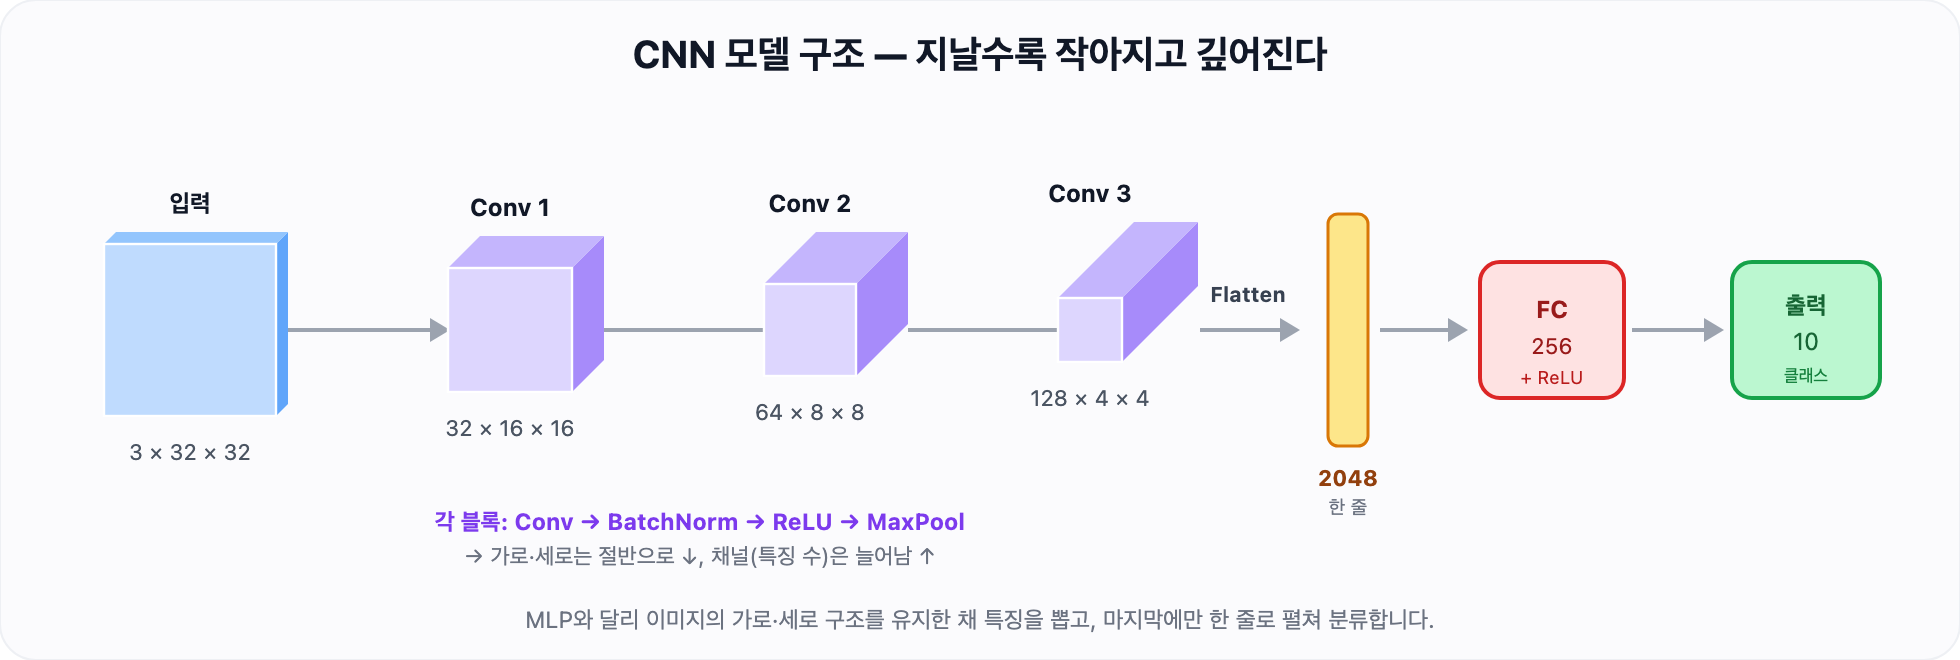
</div>

### 3-3. 하이퍼파라미터 설정 🔧
| 파라미터 | 현재 값 | 실험 아이디어 |
|----------|---------|--------------|
| `channels` | [32, 64, 128] | [64, 128, 256] → 더 많은 필터 |
| `learning_rate` | 1e-4 | 1e-3 vs 1e-5 |
| `batch_size` | 64 | 32, 128 |
| `max_epoch` | 20 | 더 늘려보기 |

In [ ]:
# ✏️ 여기서 하이퍼파라미터를 바꿔보세요!
channels      = [32, 64, 128]  # 각 Conv 레이어의 필터 수
learning_rate = 1e-4
batch_size    = 64
max_epoch     = 10    # Colab GPU 기준 약 3분

### 3-4. CNN 모델 만들기 🔧

Conv 블록 3개로 특징을 뽑고, 마지막에 완전연결층(FC)으로 10개 클래스 점수를 출력합니다. 모델을 만들고 옵티마이저까지 설정합니다.

#### 🔧 [직접 해보세요] Conv 레이어 하나 더 추가하기
현재 모델은 Conv 블록이 3개입니다. **4번째 블록을 추가**해보세요.  
블록이 하나 늘수록 이미지가 절반 크기로 줄어드니 FC 입력 크기도 함께 바꿔야 합니다!

```
현재:   32×32 → 16×16 → 8×8 → 4×4   (FC 입력: channels[-1] × 4 × 4)
추가 후: 32×32 → 16×16 → 8×8 → 4×4 → 2×2  (FC 입력: ??? × 2 × 2)
```

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, channels[0], kernel_size=3, padding=1),
            nn.BatchNorm2d(channels[0]),  # 출력값 정규화 → 학습 안정화
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(channels[0], channels[1], kernel_size=3, padding=1),
            nn.BatchNorm2d(channels[1]),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(channels[1], channels[2], kernel_size=3, padding=1),
            nn.BatchNorm2d(channels[2]),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        # ✏️ TODO: conv_block4 를 여기에 추가해보세요!
        # channels 리스트도 [32, 64, 128, 256] 으로 늘려야 합니다.

        fc_input = channels[-1] * 4 * 4  # ✏️ block4 추가 시 × 2 × 2 로 변경
        self.classifier = nn.Sequential(
            nn.Linear(fc_input, 256),
            nn.ReLU(),
            # nn.Dropout(0.3),   # ✏️ 나중에 주석 해제해보세요! (overfitting 방지)
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        # ✏️ TODO: conv_block4 호출을 여기에 추가해보세요!
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model     = CNN(num_classes=10)
model     = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\n전체 파라미터 수: {total_params:,}개')


In [ ]:
# 👀 확인: 이미지가 각 Conv 블록을 통과하면 shape가 어떻게 변하나요?
sample_imgs_gpu = sample_imgs[:4].to(device)

# 임시 모델로 중간 결과 확인
temp_model = CNN().to(device)
temp_model.eval()

with torch.no_grad():
    x = sample_imgs_gpu
    print(f"입력:        {tuple(x.shape)}  → (배치, 채널, 높이, 너비)")

    x = temp_model.conv_block1(x)
    print(f"Conv블록1 후: {tuple(x.shape)}  → MaxPool로 32×32 → 16×16")

    x = temp_model.conv_block2(x)
    print(f"Conv블록2 후: {tuple(x.shape)}  → MaxPool로 16×16 → 8×8")

    x = temp_model.conv_block3(x)
    print(f"Conv블록3 후: {tuple(x.shape)}  → MaxPool로 8×8 → 4×4")

    x_flat = x.view(x.size(0), -1)
    print(f"Flatten 후:  {tuple(x_flat.shape)}  → {x.shape[1]}×{x.shape[2]}×{x.shape[3]} = {x_flat.shape[1]}개 숫자")

    out = temp_model.classifier(x_flat)
    print(f"최종 출력:   {tuple(out.shape)}  → 클래스 10개에 대한 점수")

print()
print("✅ 이미지가 점점 작아지면서 핵심 특징만 압축됩니다!")

In [ ]:
# 👀 확인: 모델에 이미지를 넣으면 무엇이 나오나요?
sample_imgs_check, sample_labels_check = next(iter(test_dataloader))
sample_img  = sample_imgs_check[:1].to(device)
true_label  = sample_labels_check[0].item()

# 어떤 이미지인지 먼저 확인
plt.imshow(denormalize(sample_imgs_check[0]).permute(1, 2, 0).clamp(0, 1))
plt.title(f'Input image  (true label: {CLASS_NAMES[true_label]})')
plt.axis('off')
plt.show()

model.eval()
with torch.no_grad():
    output = model(sample_img)

print(f'입력 shape: {sample_img.shape}  →  출력 shape: {output.shape}')
print()
print('각 클래스별 점수:')
scores = output[0].cpu()
for i, (name, val) in enumerate(zip(CLASS_NAMES, scores)):
    bar    = '█' * int((val - scores.min()).item() * 15 / (scores.max() - scores.min()).item() + 1)
    marker = '  ← 예측!' if i == scores.argmax().item() else ''
    print(f'  {name:4s}: {val:6.3f}  {bar}{marker}')
print()
correct = scores.argmax().item() == true_label
print(f'정답: {CLASS_NAMES[true_label]}  |  예측: {CLASS_NAMES[scores.argmax().item()]}  →  {"✅ 정답!" if correct else "❌ 오답"}')


# 🏋️ STEP 4 · 학습

준비한 데이터로 CNN을 학습시킵니다. **학습/평가 함수를 정의 → 에폭을 돌며 학습**합니다.

**🔁 학습은 이 네 단계를 계속 반복하는 것** — 아래 그림이 `train()` 함수가 하는 일입니다.

<div align="center">
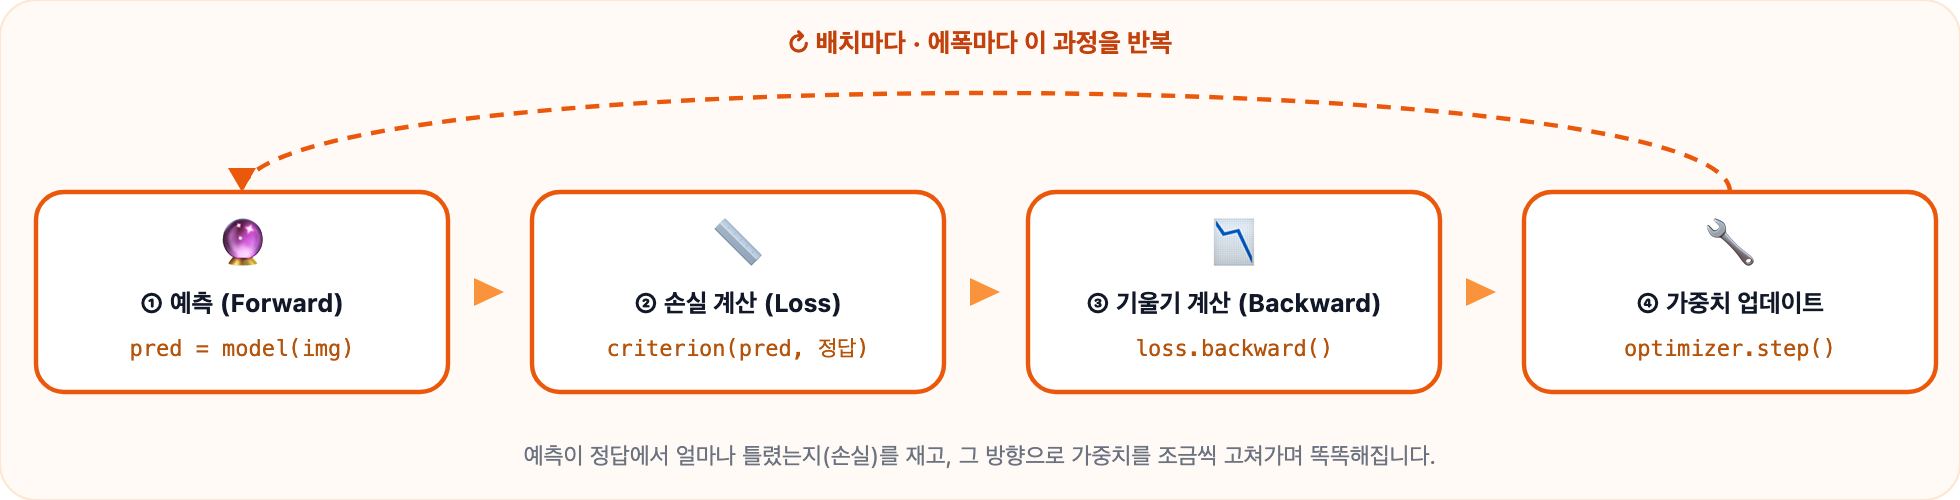
</div>

### 4-1. 학습 / 평가 함수 정의

**학습(train)**: 역전파로 가중치를 업데이트합니다.
**평가(evaluate)**: validation / test에 모두 사용하며, 가중치를 업데이트하지 않습니다.

In [ ]:
def train(model, optimizer, imgs, labels):
    model.train()
    criterion = nn.CrossEntropyLoss()

    imgs, labels = imgs.to(device), labels.to(device)

    pred = model(imgs)
    loss = criterion(pred, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    num_correct = (torch.argmax(pred, dim=1) == labels).sum().item()
    return loss.item(), num_correct

In [ ]:
def evaluate(model, imgs, labels):
    model.eval()  # 평가 모드 (Dropout 비활성화)
    criterion = nn.CrossEntropyLoss()

    imgs, labels = imgs.to(device), labels.to(device)

    with torch.no_grad():  # gradient 계산 불필요 → 메모리/속도 절약
        pred        = model(imgs)
        loss        = criterion(pred, labels)
        num_correct = (torch.argmax(pred, dim=1) == labels).sum().item()

    return loss.item(), num_correct


### 4-2. 학습 실행

매 에폭(epoch)마다 전체 데이터를 한 번씩 학습하고, 검증(validation) 성능을 확인합니다. 학습이 끝나면 테스트로 딱 한 번 최종 평가합니다.

In [ ]:
# 매번 새로운 weight로 시작
model     = CNN(num_classes=10)
model     = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# batch_size 반영을 위해 DataLoader 재생성
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_dataloader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print_every      = 2
tr_loss_history  = []
val_loss_history = []

for epoch in tqdm(range(max_epoch)):
    # ── 학습 ──────────────────────────
    train_loss, train_correct = 0.0, 0
    for imgs, labels in train_dataloader:
        loss, correct  = train(model, optimizer, imgs, labels)
        train_loss    += loss    / len(train_dataloader)
        train_correct += correct
    tr_loss_history.append(train_loss)
    torch.save(model.state_dict(), 'cnn_recent.pth')

    # ── Validation (매 에폭마다) ───────
    val_loss, val_correct = 0.0, 0
    for imgs, labels in val_dataloader:
        loss, correct  = evaluate(model, imgs, labels)
        val_loss      += loss    / len(val_dataloader)
        val_correct   += correct
    val_loss_history.append(val_loss)

    if (epoch + 1) % print_every == 0:
        train_acc = train_correct / len(train_dataset)
        val_acc   = val_correct   / len(val_dataset)
        print(f'[Epoch {epoch+1:2d}] '
              f'Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f} | '
              f'Train Acc: {train_acc:.1%} | Val Acc: {val_acc:.1%}')

# ── 최종 Test 평가 (딱 한 번) ────────
test_loss, test_correct = 0.0, 0
for imgs, labels in test_dataloader:
    loss, correct  = evaluate(model, imgs, labels)
    test_loss     += loss    / len(test_dataloader)
    test_correct  += correct
print(f'\n최종 Test Accuracy: {test_correct / len(test_dataset):.1%}')


# 📊 STEP 5 · 평가 & 결과

학습이 잘 됐는지 확인합니다. **학습 곡선으로 추세를 보고 → 실제 예측 결과**를 눈으로 확인합니다.

### 5-1. 학습 곡선 시각화

Train/Val Loss가 같이 줄어드는지 확인하세요! 함께 줄어들면 정상, train만 줄고 val이 오르면 overfitting입니다.

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(tr_loss_history,  label='Train Loss')
plt.plot(val_loss_history, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train & Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Overfitting 간단 진단
if len(val_loss_history) >= 5:
    early_val = min(val_loss_history[:-3])
    late_val  = min(val_loss_history[-3:])
    if late_val > early_val + 0.05:
        print(f'⚠️  Overfitting 의심! Val loss 최저점({early_val:.3f}) 대비 다시 오르고 있습니다 ({late_val:.3f})')
        print('   → Dropout 주석을 해제하거나, 모델을 단순하게 만들어보세요.')
    else:
        print(f'✅ 정상 학습 (Train: {tr_loss_history[-1]:.3f}, Val: {val_loss_history[-1]:.3f})')


### 5-2. 예측 결과 시각화

실제로 모델이 어떻게 분류하는지 확인해봅시다!

In [ ]:
imgs, labels = next(iter(test_dataloader))

model.eval()
with torch.no_grad():
    pred_labels = torch.argmax(model(imgs.to(device)), dim=1).cpu()

num_show = min(10, imgs.shape[0])

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flat

for i in range(num_show):
    ax = axes[i]

    img = denormalize(imgs[i]).permute(1, 2, 0).clamp(0, 1)
    ax.imshow(img)

    correct = pred_labels[i] == labels[i]
    color   = 'blue' if correct else 'red'

    ax.set_title(
        f'GT: {CLASS_NAMES[labels[i].item()]}\nPred: {CLASS_NAMES[pred_labels[i].item()]}',
        color=color,
        fontsize=9
    )
    ax.axis('off')

for j in range(num_show, 10):
    axes[j].axis('off')

plt.suptitle('Blue=Correct,  Red=Wrong', fontsize=12)
plt.tight_layout()
plt.show()